In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
np.random.seed(42)

**Сгенирируем признаки**

In [155]:
X, y, true_coef = make_regression(
    n_samples=2000,
    n_features=5,
    n_informative=5,
    shuffle=True,
    coef=True,
    random_state=42,
    noise=15
)

In [156]:
print(f"  Среднее:      {np.mean(y):.4f}")
print(f"  Медиана:      {np.median(y):.4f}")
print(f"  Станд. откл.: {np.std(y):.4f}")
print(f"  Мин:          {np.min(y):.4f}")
print(f"  Макс:         {np.max(y):.4f}")
print(f"  Размах:       {np.max(y) - np.min(y):.4f}")

  Среднее:      0.7264
  Медиана:      1.1321
  Станд. откл.: 69.0233
  Мин:          -293.1907
  Макс:         262.4979
  Размах:       555.6886


**Искуственно масштабируем признаки**

In [157]:
scales = [1, 10, 1000, 0.1, 0.01]
X = X * scales

**Разделим дата сет на тренировочную и тестовую выборки**

In [158]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
y_train= y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)
y = y.reshape(-1,1)

**Приводим все признаки к одному масштабу: mean=0, std=1**

**Это необходимо для корректной работы градиентного спуска**

In [197]:
mean_train = X_train.mean(axis=0)
mean_test = X_test.mean(axis=0)
mean = X.mean(axis=0)
std = X.std(axis=0)
std_train = X_train.std(axis=0)
std_test = X_test.std(axis=0)
X_norm = (X - mean) / std
X_norm_test = (X_test - mean_test) / std_test
X_norm_train = (X_train - mean_train) / std_train

**Добавляем столбец единиц к матрице признаков X для того, чтобы модель смогла обучить свободный член**

In [198]:
X_norm_test = np.column_stack([X_norm_test,np.ones(len(X_norm_test))])
X_norm_train = np.column_stack([X_norm_train,np.ones(len(X_norm_train))])
X_norm = np.column_stack([X_norm,np.ones(len(X_norm))])

In [202]:
w = np.random.randn(X_norm.shape[1]) * 0.01
w = w.reshape(-1,1)

**Напиши функцию для подсчета MSE и градиента MSE**

In [203]:
def mse(X, y, w):
    return np.mean((X @ w - y) ** 2)

def grad_MSE(X, y, w):
    return X.T @ (X @ w - y) / len(X)

**Тестируем разные lr, чтобы найти оптимальный**


**Строим графики сходимости для визуального сравнения**

Количество итераций:  1999
learning_rate: 0.001
[[28.65222379  8.0647507   8.70029027 49.03159365  6.81867641  0.62732782]]

Количество итераций:  1999
learning_rate: 0.003
[[33.27907517  9.34461201 10.63293638 56.75066247  7.7390751   0.72463771]]

Количество итераций:  1368
learning_rate: 0.01
[[33.37431989  9.37062213 10.68965709 56.90130937  7.75284559  0.72643772]]

Количество итераций:  489
learning_rate: 0.03
[[33.37435507  9.37063194 10.68968612 56.90135962  7.75284892  0.72643825]]

Количество итераций:  154
learning_rate: 0.1
[[33.37436759  9.37063545 10.68969683 56.90137719  7.75285005  0.72643843]]



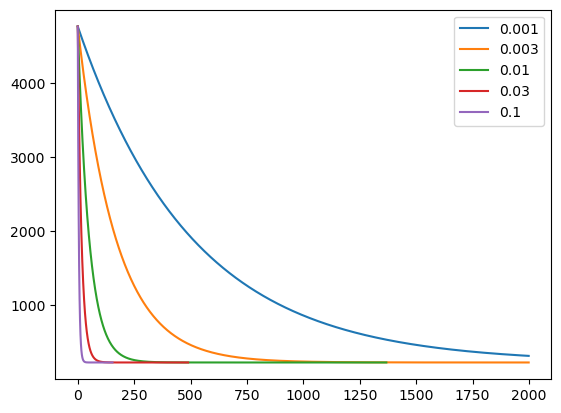

In [204]:
learning_rates = [0.001, 0.003, 0.01, 0.03, 0.1]

eps = 0.000001

max_iter = 2000


for ind in range(len(learning_rates)):

  next_w = w
  mse_ls = []

  for i in range(max_iter):

    cur_w = next_w

    next_w = cur_w - learning_rates[ind] * grad_MSE(X_norm,y,cur_w)
    mse_ls.append(mse(X_norm,y,cur_w))
    if np.linalg.norm(cur_w - next_w, ord=2) <= eps:
        break
  sns.lineplot(x=np.arange(0,i+1),y=mse_ls,label=f'{learning_rates[ind]}')
  print('Количество итераций: ',i)
  print(f"learning_rate: {learning_rates[ind]}")
  print(next_w.reshape(1,-1))
  print()

**Класс-обертка для обучения модели и вывода метрик**

In [205]:
class model:

    learning_rates = 0.1
    eps = 0.000001
    max_iter = 750


    def __init__(self):

        self.w = None

    def MSE(self, X, y):
        if self.w is None:
          raise ValueError("Модель не обучена")

        return np.mean((X @ self.w - y) ** 2)

    def grad_MSE(self, X, y, w):
      return X.T @ (X @ w - y) / len(X)

    def RMSE(self, X, y):
        return np.sqrt(self.MSE(X, y))

    def MAE(self,X,y):
      if self.w is None:
          raise ValueError("Модель не обучена")

      return np.mean(np.abs((X @ self.w - y)))

    def MAPE(self, X, y):
        if np.any(y == 0):
            return np.nan
        return np.mean(np.abs((y - X @ self.w) / y)) * 100
    
    def R2(self,X,y):
        if self.w is None:
            raise ValueError("Модель не обучена")
        vr = np.var(y)
        ms = self.MSE(X,y)
        return (1 - (ms/vr)) * 100
    def learn(self, X, y):
        next_w = np.random.randn(X.shape[1]) * 0.01
        next_w = next_w.reshape(-1,1)

        for i in range(self.max_iter):

            cur_w = next_w

            next_w = cur_w - self.learning_rates * self.grad_MSE(X, y, cur_w)


            if np.linalg.norm(cur_w - next_w, ord=2) <= self.eps:
                break

        self.w = next_w

    def predict(self,X):
      if self.w is None:
            raise ValueError("Модель не обучена")
      return  X @ self.w

    def getMetrics(self, X, y):
        return {'MSE': self.MSE(X, y),
            'RMSE': self.RMSE(X, y),
            'MAE': self.MAE(X, y),
            'MAPE': self.MAPE(X, y),
            'R2': self.R2(X, y)}
    
    def print_metrics(self, X, y):
      print(f"MSE: {self.MSE(X, y):.4f}")
      print(f"RMSE: {self.RMSE(X, y):.4f}")
      print(f"MAE:  {self.MAE(X, y):.4f}")
      print(f"MAPE: {self.MAPE(X, y):.2f}%")
      print(f"R2: {self.R2(X, y):.2f}%")

**Обучим модель**

In [206]:
mod = model()
mod.learn(X_norm_train,y_train)
y_t = mod.predict(X_norm_test)

In [207]:
mod.print_metrics(X_norm_train,y_train)

MSE: 234.3786
RMSE: 15.3094
MAE:  12.1811
MAPE: 128.21%
R2: 95.04%


In [208]:
mod.print_metrics(X_norm_test,y_test)

MSE: 220.0019
RMSE: 14.8325
MAE:  11.6666
MAPE: 72.19%
R2: 95.51%


**Вывод:** MAPE — неинформативен из-за наличия отрицательных    и близких к нулю значений в целевой переменной. Также заметим, что метрика R2 на обучающей и тестовой выборке соввпадают, что значит отсутствие переобучение у модели.

In [209]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmses = []
for train_index, test_index in kf.split(X_train):
    X_tr,X_t = X_norm_train[train_index], X_norm_train[test_index]
    Y_tr,Y_t = y_train[train_index], y_train[test_index]
    print('------------------------------------------------')
    mod.learn(X_tr,Y_tr)
    mod.print_metrics(X_t,Y_t)
    rmses.append(mod.getMetrics(X_t,Y_t)['RMSE'])
print('---------RESULT---------------------------------')
print(f'Mean RMSE:  {np.mean(rmses):.4f}')
print(f'std RMSE:  {np.std(rmses):.4f}')

------------------------------------------------
MSE: 228.4604
RMSE: 15.1149
MAE:  12.2353
MAPE: 67.54%
R2: 94.65%
------------------------------------------------
MSE: 256.2382
RMSE: 16.0074
MAE:  12.7829
MAPE: 90.20%
R2: 94.74%
------------------------------------------------
MSE: 240.4171
RMSE: 15.5054
MAE:  12.3646
MAPE: 106.25%
R2: 95.25%
------------------------------------------------
MSE: 246.1780
RMSE: 15.6901
MAE:  12.0441
MAPE: 85.13%
R2: 94.92%
------------------------------------------------
MSE: 207.4170
RMSE: 14.4020
MAE:  11.6164
MAPE: 289.34%
R2: 95.39%
---------RESULT---------------------------------
Mean RMSE:  15.3440
std RMSE:  0.5524


**Выводы:** Для проверки устойчивости модели была проведена 5-fold кросс-валидация. Средняя **RMSE** по фолдам составила **15.3440** при стандартном отклонении **0.5524**, что говорит о высокой стабильности модели. Разброс значений RMSE между фолдами находится в диапазоне от **14.4020 до 16.0074**, что свидетельствует о небольшой чувствительности модели к изменению обучающей выборки. Это является признаком **низкого variance** и хорошей обобщающей способности модели. В совокупности с близкими значениями метрик на обучающей и тестовой выборках результаты не дают явных признаков переобучения.


In [210]:
mod_sk = LinearRegression(fit_intercept=False)
mod_sk.fit(X_norm_train,y_train)

,fit_intercept,False
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Сравним полученные веса модели с весами модели из библиотеки sklear**

In [195]:
print((mod.w).reshape(-1))

[32.95438953  9.4047206  10.73834965 57.1000774   7.74479892  1.35526397]


In [196]:
print((mod_sk.coef_).reshape(-1))

[32.85898072  9.41602933 10.79614874 57.06959963  7.83649501  1.44821182]
